In [2]:
from robot_vlp.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, MODELS_DIR, EXPERIMENT_DATA_DIR
import pickle
import numpy as np
import keras
import robot_vlp.data.preprocessing as p
import matplotlib.pyplot as plt
import robot_vlp.data_collection.communication as c
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.models import Model
import kerastuner as kt
from tensorflow.keras.callbacks import ReduceLROnPlateau
import robot_vlp.data_collection.experment_processing as ep

import robot_vlp.modeling.gen_cnc_vlp_model as vlp

from robot_vlp.modeling.rnn import ang_loss_fn

import robot_vlp.data.odometer_path_navigation as pg
import robot_vlp.plots.model_performance_plotting as pp
import robot_vlp.modeling.rnn as rnn

%load_ext autoreload
%autoreload 2

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/var/folders/j0/3mr_0p157c9d4qgnmrzwc8nm0000gn/T/ipykernel_95134/3797339399.py:16: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [3]:
def vec_to_ang(pre_ang):
    return np.arctan2(pre_ang[:,0], pre_ang[:,1]) * 180/ np.pi

def normalize_angle_deg(angle):
    """Normalize an angle in degrees to the range [-180, 180]."""
    return (angle + 180) % 360 - 180

def expand(y):
    y_rad = y[:,2] * np.pi / 180
    y_angles = np.column_stack((np.sin(y_rad), np.cos(y_rad)))
    return [y[:,:2], y_angles]\
    
def calc_loc_err(pre, true):
    x_d = pre[:,0] - true[:,0]
    y_d = pre[:,1] - true[:,1]
    errs = np.sqrt(np.square(x_d) + np.square(y_d))
    return errs

# Define a cosine similarity–based loss function for headings
def cosine_loss(y_true, y_pred):
    # Use tf.keras.losses.CosineSimilarity which returns negative values (max similarity = -1)
    cos_sim = tf.keras.losses.CosineSimilarity(axis=1)(y_true, y_pred)
    # Convert to a loss (0 when identical, higher when misaligned)
    return 1 + cos_sim  # When vectors are identical, cos_sim = -1, so loss becomes 0


vlp_models = vlp.load_vlp_models()
vlp_model = vlp_models['high_acc']
df_lst = []
for i in range(3,13):
    path = EXPERIMENT_DATA_DIR/f'Robot/exp1_{i}.csv'
    df_lst.append(ep.process_robot_exp_file(path, vlp_model))


X_lst =  []
y_lst = []

for df in df_lst[2:]:
    df = df.dropna()

    X =  df[['vlp_x_hist', 'vlp_y_hist','vlp_heading_hist','vlp_heading_change', 'encoder_heading_change', 'encoder_heading_hist', 'encoder_x_hist','encoder_y_hist']].values
    y = df[['x_hist', 'y_hist','heading_hist']].values

    X_lst.append(X)
    y_lst.append(y)

X_train = np.concatenate(X_lst[:-2])
y_train = np.concatenate(y_lst[:-2])

X_valid = X_lst[-2]
y_valid = y_lst[-2]

X_test = X_lst[-1]
y_test = y_lst[-1]


scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

2025-02-12 21:20:17.958 | SUCCESS  | robot_vlp.data_collection.experment_processing:process_robot_exp_file:69 - opending file: 
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
2025-02-12 21:20:22.515 | SUCCESS  | robot_vlp.data_collection.experment_processing:process_robot_exp_file:69 - opending file: 
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step


/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


2025-02-12 21:20:26.968 | SUCCESS  | robot_vlp.data_collection.experment_processing:process_robot_exp_file:69 - opending file: 
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step


...

/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


2025-02-12 21:20:49.552 | SUCCESS  | robot_vlp.data_collection.experment_processing:process_robot_exp_file:69 - opending file: 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step


/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


2025-02-12 21:20:51.389 | SUCCESS  | robot_vlp.data_collection.experment_processing:process_robot_exp_file:69 - opending file: 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step


/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/tyrelglass/miniforge3/envs/robot-vlp/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [8]:
# Define a hypermodel function
def build_model(hp):
    inputs = keras.Input(shape=(X_train.shape[1],))
    
    # Hyperparameter: number of layers (between 1 and 3)
    num_layers = hp.Int("num_layers", min_value=1, max_value=3, step=1)
    x = inputs
    for i in range(num_layers):
        units = hp.Int(f"units_{i}", min_value=32, max_value=256, step=32)
        activation = hp.Choice(f"activation_{i}", values=["relu", "tanh", "elu","leaky_relu"])
        init = hp.Choice(f"kernel_init_{i}", values=["glorot_uniform", "he_normal"])
        reg = hp.Float(f"kernel_reg_{i}", min_value=1e-5, max_value=1e-2, sampling="LOG", default=1e-4)

        if activation == "leaky_relu":
            x = layers.Dense(units, kernel_initializer=init, kernel_regularizer=tf.keras.regularizers.l2(reg))(x)
            x = layers.LeakyReLU(alpha=0.1)(x)
        else:
            x = layers.Dense(units, activation=activation, kernel_initializer=init, 
                             kernel_regularizer=tf.keras.regularizers.l2(reg))(x)

        # Optionally, add batch normalization
        if hp.Boolean(f"batch_norm_{i}"):
            x = layers.BatchNormalization()(x)
        # Optionally, add dropout
        dropout_rate = hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    loc_output = Dense(2, activation='linear', name='loc_output')(x)
    angle_output = Dense(2, activation='tanh', name='angle_output')(x)

    model = Model(inputs=[inputs], outputs=[loc_output, angle_output])
    
    # Hyperparameter: learning rate for the optimizer
    lr = hp.Float("lr", min_value=1e-5, max_value=1e-2, sampling="LOG")
    # Hyperparameter: optimizer choice
    optimizer_choice = hp.Choice("optimizer", values=["adam", "rmsprop", "nadam"])
    if optimizer_choice == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_choice == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = keras.optimizers.Nadam(learning_rate=lr)


    # Hyperparameter for selecting the heading loss function:
    heading_loss_type = hp.Choice("heading_loss", values=["mse", "cosine"])
    if heading_loss_type == "mse":
        heading_loss = "mse"
    else:
        heading_loss = cosine_loss  

    model.compile(optimizer= optimizer, loss=['mean_squared_error', heading_loss], loss_weights= [1.0, 1.0])
    return model

## Run hyperparameter tuning

In [ ]:
# Set up the tuner, for example using Hyperband
tuner = kt.Hyperband(
    build_model,
    objective="val_loss",
    max_epochs=50,
    factor=3,
    directory="my_dir",
    project_name="hyperparam_tuning_demo", 
    overwrite = True
)

# Optionally, add an early stopping callback
stop_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10)

# Create the ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor the validation loss
    factor=0.5,          # Reduce the LR by this factor when a plateau is detected
    patience=5,          # Wait for 5 epochs with no improvement before reducing LR
    verbose=1,
    min_lr=1e-6          # Do not reduce below this LR
)



# Run the hyperparameter search
tuner.search(X_train_scaled, expand(y_train), epochs=50, validation_split=0.2, callbacks=[stop_early, reduce_lr])

# Retrieve the best model and hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(f"  Number of layers: {best_hps.get('num_layers')}")
for i in range(best_hps.get("num_layers")):
    print(f"  Layer {i} units: {best_hps.get(f'units_{i}')}")
    print(f"  Layer {i} activation: {best_hps.get(f'activation_{i}')}")
    print(f"  Batch norm layer {i}: {best_hps.get(f'batch_norm_{i}')}")
    print(f"  Dropout rate layer {i}: {best_hps.get(f'dropout_{i}')}")
print(f"  Learning rate: {best_hps.get('lr')}")
print(f"  Optimizer: {best_hps.get('optimizer')}")

# Build the best model and train it further if desired
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    x = X_train_scaled, 
    y = expand(y_train),
    validation_data = (X_valid_scaled,  expand(y_valid)),
    epochs=300, 
    batch_size=16, 
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), reduce_lr] )

pre_loc, pre_ang = best_model.predict(X_test_scaled)
loc_errs = calc_loc_err(pre_loc, y_test[:,:2])

print('Location errors: ',loc_errs.mean())

ang_errs = vec_to_ang(pre_ang) - y_test[:,2]
ang_errs = np.array([normalize_angle_deg(ang) for ang in ang_errs])

print('heading errs: ',np.abs(ang_errs).mean())

## Build default model

In [9]:
from kerastuner import HyperParameters

# Create a HyperParameters object and set fixed values.
hp = HyperParameters()
hp.Fixed("num_layers", 1)
hp.Fixed("units_0", 100)                  # Single hidden layer of 100 neurons
hp.Fixed("activation_0", "relu")          # Default activation is ReLU
hp.Fixed("kernel_init_0", "glorot_uniform")
hp.Fixed("kernel_reg_0", 1e-4)             # Equivalent to alpha in scikit-learn
hp.Fixed("batch_norm_0", False)
hp.Fixed("dropout_0", 0.0)
hp.Fixed("lr", 1e-3)                      # Learning rate of 0.001
hp.Fixed("optimizer", "adam")             # Adam is the default solver in scikit-learn
hp.Fixed("heading_loss", "mse")           # Use MSE for the heading output loss

# Now build the model with these hyperparameters
model = build_model(hp)
model.summary()


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100)       │        900 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ loc_output (Dense)  │ (None, 2)         │        202 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ angle_output        │ (None, 2)         │        202 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,304 (5.09 KB)

 Trainable params: 1,304 (5.09 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    x = X_train_scaled, 
    y = expand(y_train),
    validation_data = (X_valid_scaled,  expand(y_valid)),
    epochs=300, 
    batch_size=32, 
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)] )


pre_loc, pre_ang = model.predict(X_test_scaled)
loc_errs = calc_loc_err(pre_loc, y_test[:,:2])

print('Location errors: ',loc_errs.mean())

ang_errs = vec_to_ang(pre_ang) - y_test[:,2]
ang_errs = np.array([normalize_angle_deg(ang) for ang in ang_errs])

print('heading errs: ',np.abs(ang_errs).mean())

Epoch 1/300
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - angle_output_loss: 0.0120 - loc_output_loss: 7.9548e-04 - loss: 0.0148 - val_angle_output_loss: 0.0078 - val_loc_output_loss: 0.0014 - val_loss: 0.0105
Epoch 2/300
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - angle_output_loss: 0.0124 - loc_output_loss: 7.9674e-04 - loss: 0.0152 - val_angle_output_loss: 0.0086 - val_loc_output_loss: 0.0015 - val_loss: 0.0113
Epoch 3/300
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - angle_output_loss: 0.0122 - loc_output_loss: 7.8599e-04 - loss: 0.0150 - val_angle_output_loss: 0.0084 - val_loc_output_loss: 0.0015 - val_loss: 0.0111
Epoch 4/300
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - angle_output_loss: 0.0117 - loc_output_loss: 7.8687e-04 - loss: 0.0144 - val_angle_output_loss: 0.0075 - val_loc_output_loss: 0.0016 - val_loss: 0.0102
Epoch 5/300
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - angle_output_loss: 0.0115 - loc_output_loss: 7.4959e-04 - loss: 0.0142 - val_angle_output_loss: 0.0080 - va

In [30]:
vlp_ang_errs = y_test[:,2] -  X_test[:,2]
vlp_ang_errs = np.array([normalize_angle_deg(ang) for ang in vlp_ang_errs])

(array([  2.,   7.,  23., 106., 159.,  43.,   8.,   3.,   0.,   1.]),
 array([-47.82993249, -36.36815885, -24.9063852 , -13.44461155,
         -1.9828379 ,   9.47893575,  20.9407094 ,  32.40248305,
         43.86425669,  55.32603034,  66.78780399]),
 <BarContainer object of 10 artists>)

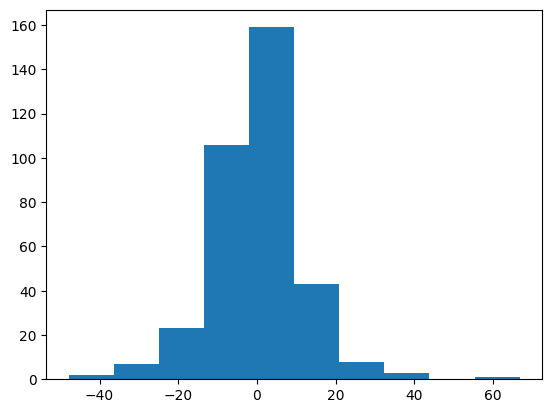

In [32]:
plt.hist(vlp_ang_errs)

In [33]:
np.abs(vlp_ang_errs).mean()

8.364116223020115